# Spatial Autocorrelation Analysis

A self-contained, worked example of measuring **spatial autocorrelation** — the
degree to which nearby locations tend to have similar values — on 2-D point data
using **Moran's *I*** and **Local Indicators of Spatial Association (LISA)**.

The workflow is:

1. Generate several synthetic spatial patterns (random, gradient, clustered, dispersed).
2. Select a neighborhood size *k* for a k-nearest-neighbors spatial weights matrix.
3. Compute **global Moran's *I*** to test for autocorrelation across the whole dataset.
4. Compute **Local Moran's *I* (LISA)** to locate individual clusters and outliers.
5. Visualize the input values and each of the LISA results.

## Background

- **Global Moran's *I*** summarizes the overall spatial pattern in a single statistic.
  Positive values mean similar values cluster together; negative values mean high and
  low values are interspersed (dispersion); values near zero indicate no spatial structure.
- **Local Moran's *I* (LISA)** decomposes that global measure per observation, classifying
  each point as High-High or Low-Low (clusters) or High-Low or Low-High (spatial outliers),
  each with its own significance value.

## Requirements

Python 3.9+ and the packages listed in `requirements.txt`:

```bash
pip install -r requirements.txt
```

In [1]:
# Ensure all required packages are installed before running.
%pip install -q -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import libpysal.weights as weights
import esda

print("[OK] Dependencies installed and libraries imported.")

Note: you may need to restart the kernel to use updated packages.

[OK] Dependencies installed and libraries imported.


## 1. Generate synthetic datasets

Six spatial patterns are created so the analysis can be run against known ground truth.
Choose which one to analyze by editing the last line of the cell:

| Variable | Pattern |
| --- | --- |
| `df_rando` | Uniformly random quality values |
| `df_gradient1` | Smooth low → high gradient |
| `df_gradient2` | High near the origin, mixing outward |
| `df_gradient3` | Gradient with a high value seeded near each pair of low values |
| `df_dispersed` | High and low values interleaved by quadrant |
| `df_dispersed_eq` | Same as above, on a perfectly equidistant grid *(default)* |

In [2]:
##################### Generate dummy data ############################

# Random distribution of quality along x and y
np.random.seed(42)  # for reproducibility
data = {
    'x': np.random.rand(200) * 100,
    'y': np.random.rand(200) * 100,
    'quality': np.random.rand(200)
}
df_rando = pd.DataFrame(data)

# Gradient of quality values along x and y with clustering of high and low values
# Generate random x and y values
x_values = np.random.rand(200) * 100
y_values = np.random.rand(200) * 100

# Normalize x and y to be between 0 and 1
x_normalized = (x_values - x_values.min()) / (x_values.max() - x_values.min())
y_normalized = (y_values - y_values.min()) / (y_values.max() - y_values.min())

# Generate 'quality' as the average of normalized 'x' and 'y'
quality = 0.5 * (x_normalized + y_normalized)

data = {
    'x': x_values,
    'y': y_values,
    'quality': quality
}
df_gradient1 = pd.DataFrame(data)

# Gradient of quality values with different weightings from the one above (more intermixing of quality values)
np.random.seed(42)  # for reproducibility

# Generate random x and y values
x_values = np.random.rand(200) * 100
y_values = np.random.rand(200) * 100

# Calculate distances from the origin (0, 0) for each point
distances = np.sqrt(x_values**2 + y_values**2)
max_distance = np.max(distances)

# Determine quality based on distance
quality = []
for d in distances:
    if d < max_distance * 0.33:
        quality.append(np.random.uniform(0.7, 1.0))  # high-quality values close to origin
    elif d < max_distance * 0.66:
        quality.append(np.random.uniform(0.4, 0.7))  # mixed values in the middle
    else:
        quality.append(np.random.uniform(0.0, 1.0))  # even mix of low and high values far from origin

data = {
    'x': x_values,
    'y': y_values,
    'quality': quality
}
df_gradient2 = pd.DataFrame(data)

#Create distribution where a high value is placed in close proximity to every two low values in combination with the gradient above
x_values = np.random.rand(200) * 100
y_values = np.random.rand(200) * 100

# Normalize x and y to be between 0 and 1
x_normalized = (x_values - x_values.min()) / (x_values.max() - x_values.min())
y_normalized = (y_values - y_values.min()) / (y_values.max() - y_values.min())

# Generate 'quality' as the average of normalized 'x' and 'y'
quality = 0.5 * (x_normalized + y_normalized)

# Creating a DataFrame
df = pd.DataFrame({'x': x_values, 'y': y_values, 'quality': quality})

# Sort the DataFrame by quality
df = df.sort_values(by='quality')

# Introduce a high 'quality' value for every two low 'quality' values
new_rows = []
for i in range(0, len(df)-2, 3):  # step of 3 to account for two lows and one high
    low_1, low_2 = df.iloc[i], df.iloc[i+1]
    # Perturb x and y slightly to position the high 'quality' value close to the two low values
    x_high = (low_1['x'] + low_2['x']) / 2 + np.random.uniform(-2, 2)
    y_high = (low_1['y'] + low_2['y']) / 2 + np.random.uniform(-2, 2)
    quality_high = 0.9  # or another high value
    new_rows.append({'x': x_high, 'y': y_high, 'quality': quality_high})

# Add the new rows to the DataFrame
df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

# Store this distribution as df_gradient3
df_gradient3 = df

#Distribution where low and high values are evenly dispersed
# Create a grid of points
x_values = np.random.rand(200) * 100
y_values = np.random.rand(200) * 100

# Calculate the median for x and y to split into quadrants
x_median = np.median(x_values)
y_median = np.median(y_values)

# Generate 'quality' values based on quadrant
quality = []
for x, y in zip(x_values, y_values):
    if (x <= x_median and y <= y_median) or (x > x_median and y > y_median):  # bottom-left or top-right quadrant
        quality.append(np.random.choice([0.8, 0.2]))  # mix of high and low
    else:  # top-left or bottom-right quadrant
        quality.append(np.random.choice([0.8, 0.2]))  # mix of high and low

data = {
    'x': x_values,
    'y': y_values,
    'quality': quality
}
df_dispersed = pd.DataFrame(data)

# Data above but making all points equidistant from one another
# Determine the number of points along each axis for a grid
n_points = int(np.sqrt(200))  # For 200 total points, we'll have a 14x14 grid

# Create a grid of equidistant points
x_values = np.linspace(0, 100, n_points)
y_values = np.linspace(0, 100, n_points)
x_values, y_values = np.meshgrid(x_values, y_values)
x_values = x_values.flatten()
y_values = y_values.flatten()

# Calculate the median for x and y to split into quadrants
x_median = np.median(x_values)
y_median = np.median(y_values)

# Generate 'quality' values based on quadrant
quality = []
for x, y in zip(x_values, y_values):
    if (x <= x_median and y <= y_median) or (x > x_median and y > y_median):  # bottom-left or top-right quadrant
        quality.append(np.random.choice([0.8, 0.2]))  # mix of high and low
    else:  # top-left or bottom-right quadrant
        quality.append(np.random.choice([0.8, 0.2]))  # mix of high and low

data = {
    'x': x_values,
    'y': y_values,
    'quality': quality
}
df_dispersed_eq = pd.DataFrame(data)

#Uncomment the data set you want to test
#df = df_rando #Random distribution
#df = df_gradient1 #Gradient from low to high values
#df = df_gradient2 #Gradient from high to intermixing of low and high values
#df = df_gradient3 #Gradient with secondary distribution high values in low proximity to low values
#df = df_dispersed #Even dispersion of low and high values
df = df_dispersed_eq #Even dispersion of low and high values where all points are equidistant

print(f"[OK] Datasets generated - selected dataset has {len(df)} points.")

[OK] Datasets generated - selected dataset has 196 points.


## 2. Choose the neighborhood size *k*

The spatial weights matrix links each point to its *k* nearest neighbors, so *k* controls
how large each point's neighborhood is. Here it is chosen with the **elbow method**: the
within-cluster sum of squares (WCSS) from k-means is plotted against *k*, and the point of
maximum curvature — the value farthest from the straight line joining the first and last
points — is taken as the optimal *k*.

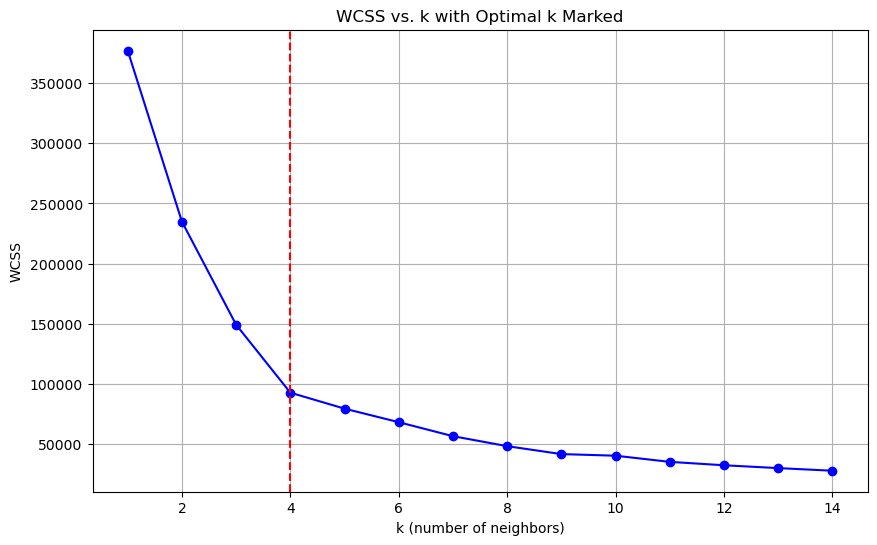

Optimal k value: 4
[OK] Optimal k selected.


In [3]:
# Determine the optimum k value for the subsequent knn function
def plot_wcss_vs_k(coordinates, k_range):
    """
    Plot WCSS against k values for k-nearest neighbors and mark the inflection point.
    
    Args:
    - coordinates (array-like): Array of x, y coordinates.
    - k_range (range): Range of k values to test.
    """
    wcss = []  # within-cluster sum of squares
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(coordinates)
        wcss.append(kmeans.inertia_)
    
    # Calculate the distance of each WCSS point to a line connecting the first and last WCSS values
    x1, y1 = k_range[0], wcss[0]
    x2, y2 = k_range[-1], wcss[-1]
    distances = []
    for k, w in zip(k_range, wcss):
        # Distance formula for a point from a line (derived from the line equation)
        distance = np.abs((y2 - y1)*k - (x2 - x1)*w + x2*y1 - y2*x1) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(distance)
    
    # Find k value corresponding to the maximum distance
    optimal_k = k_range[np.argmax(distances)]
    
    # Plot results for visualization
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.xlabel('k (number of neighbors)')
    plt.ylabel('WCSS')
    plt.title('WCSS vs. k with Optimal k Marked')
    plt.grid(True)
    plt.show()

    return optimal_k

# Extract coordinates
coordinates = df[['x', 'y', 'quality']].values

# Usage
k_range = range(1, 15)  # or another reasonable range based on your dataset
optimal_k = plot_wcss_vs_k(coordinates, k_range)
print(f"Optimal k value: {optimal_k}")

print("[OK] Optimal k selected.")

## 3. Build the spatial weights matrix

Construct a k-nearest-neighbors weights matrix using the *k* selected above. This defines
each point's neighborhood for the autocorrelation statistics that follow.

In [4]:
# Create a list of x, y coordinates
coordinates = df[['x', 'y']].values

# Construct a spatial weight matrix using k-nearest neighbors
# Using optimal k parameter per elbow tuning above
knn_w = weights.KNN(coordinates, k=optimal_k)

print(f"[OK] Spatial weights matrix built (k = {optimal_k}).")

[OK] Spatial weights matrix built (k = 4).


## 4. Global Moran's *I*

A single statistic describing the whole dataset. The observed *I* is compared to its expected
value under spatial randomness, and the permutation-based p-value indicates whether the
observed pattern is statistically significant (typically p ≤ 0.05).

In [5]:
# Compute Moran's I
moran = esda.Moran(df['quality'], knn_w)
print(f"Moran's I: {moran.I}")
print(f"Expected I under random spatial distribution: {moran.EI}")
print(f"P-value: {moran.p_sim}")

# A positive Moran's I value indicates clustering of similar values.
# A negative Moran's I value indicates dispersion of similar values.
# A Moran's I value near zero indicates randomness.
# If the p-value is below a significance level (e.g., 0.05), then the spatial pattern is statistically significant.

print("[OK] Global Moran's I computed.")

Moran's I: 0.026120970282474006
Expected I under random spatial distribution: -0.005128205128205128
P-value: 0.268
[OK] Global Moran's I computed.


## 5. Local Moran's *I* (LISA)

When the global statistic suggests spatial structure, LISA locates *where* it occurs by
decomposing Moran's *I* into a value per observation. Each point receives a local *I*, a
permutation p-value, and a quadrant label:

- **1 — High-High:** a high value surrounded by high-value neighbors (hot spot)
- **2 — Low-High:** a low value surrounded by high-value neighbors (spatial outlier)
- **3 — Low-Low:** a low value surrounded by low-value neighbors (cold spot)
- **4 — High-Low:** a high value surrounded by low-value neighbors (spatial outlier)

In [6]:
# Local Indicators of Spatial Association (LISA)
# If global indicators (like Moran's I) suggest spatial autocorrelation, you can use LISA to identify specific areas of clustering or dispersion.
# Compute Local Moran's I
local_moran = esda.Moran_Local(df['quality'], knn_w)

#print(local_moran.Is)
#print(local_moran.p_sim)
#print(local_moran.q)

# local_moran.Is: The local Moran's I values for each observation.
# local_moran.p_sim: p-values for each observation. A low p-value (typically < 0.05) indicates that the spatial autocorrelation for that observation is statistically significant.
# local_moran.q: A quadrant value (1, 2, 3, or 4) indicating the type of spatial association for each observation:
    #1: High-High (an observation with a high value surrounded by neighbors with high values)
    #2: Low-High (an observation with a low value surrounded by neighbors with high values)
    #3: Low-Low (an observation with a low value surrounded by neighbors with low values)
    #4: High-Low (an observation with a high value surrounded by neighbors with low values)

print("[OK] Local Moran's I (LISA) computed.")

[OK] Local Moran's I (LISA) computed.


## 6. Visualize the results

### Input quality values

The raw `quality` field plotted over space — the pattern the statistics are measuring.

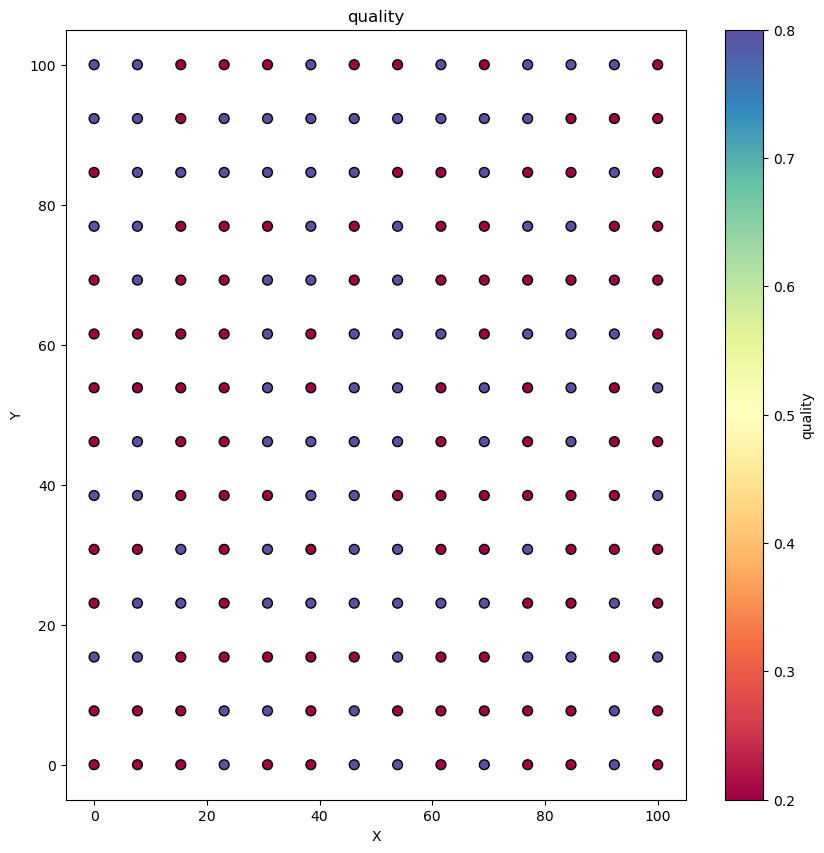

[OK] Input quality map rendered.


In [7]:
# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(df['x'], df['y'], c=df['quality'], cmap='Spectral', s=50, edgecolors='k')

# Add colorbar and labels
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('quality')
ax.set_title('quality')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

print("[OK] Input quality map rendered.")

### LISA cluster map

Statistically significant (p ≤ 0.05) clusters and outliers, colored by quadrant.
Non-significant points are shown in grey.

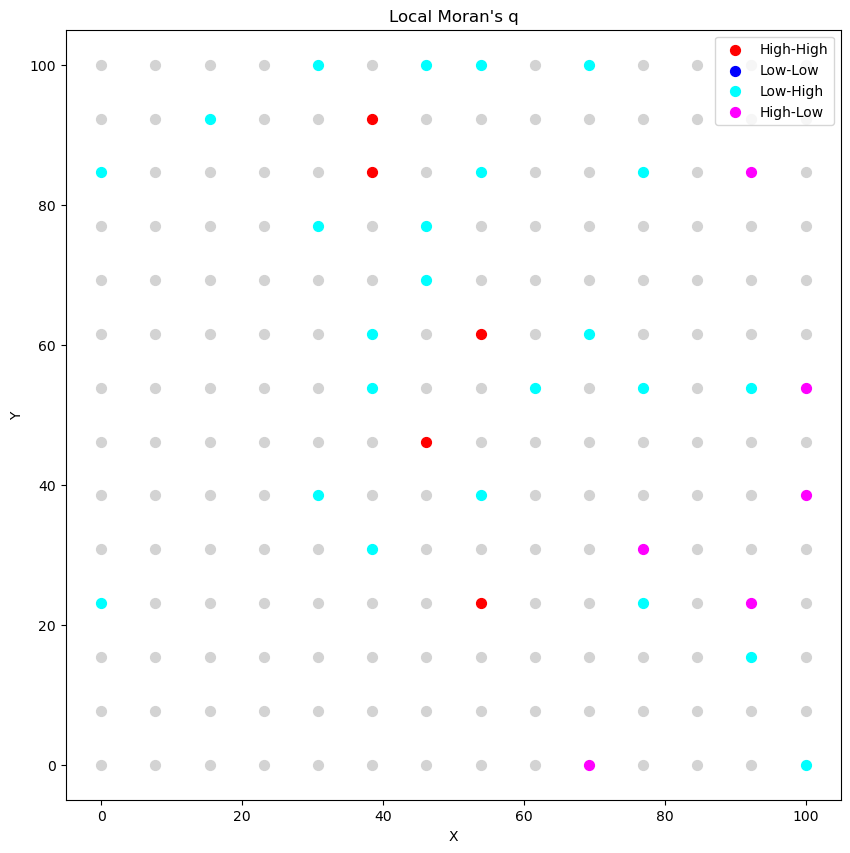

[OK] LISA cluster map rendered.


In [8]:
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Plot insignificant observations (p > 0.05) in light gray
insignificant = (local_moran.p_sim > 0.05)
ax.scatter(df['x'][insignificant], df['y'][insignificant], color='lightgrey', s=50)

# Plot High-High and Low-Low clusters (quadrants 1 and 3)
hh = (local_moran.q==1) & (local_moran.p_sim <= 0.05)
ll = (local_moran.q==3) & (local_moran.p_sim <= 0.05)
ax.scatter(df['x'][hh], df['y'][hh], color='red', s=50, label='High-High')
ax.scatter(df['x'][ll], df['y'][ll], color='blue', s=50, label='Low-Low')

# Plot Low-High and High-Low outliers (quadrants 2 and 4)
lh = (local_moran.q==2) & (local_moran.p_sim <= 0.05)
hl = (local_moran.q==4) & (local_moran.p_sim <= 0.05)
ax.scatter(df['x'][lh], df['y'][lh], color='cyan', s=50, label='Low-High')
ax.scatter(df['x'][hl], df['y'][hl], color='magenta', s=50, label='High-Low')

# Add legend and labels
ax.legend()
ax.set_title('Local Moran\'s q')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

print("[OK] LISA cluster map rendered.")

### Local Moran's *I* values

Per-point local *I*, highlighting where local spatial association is strongest.

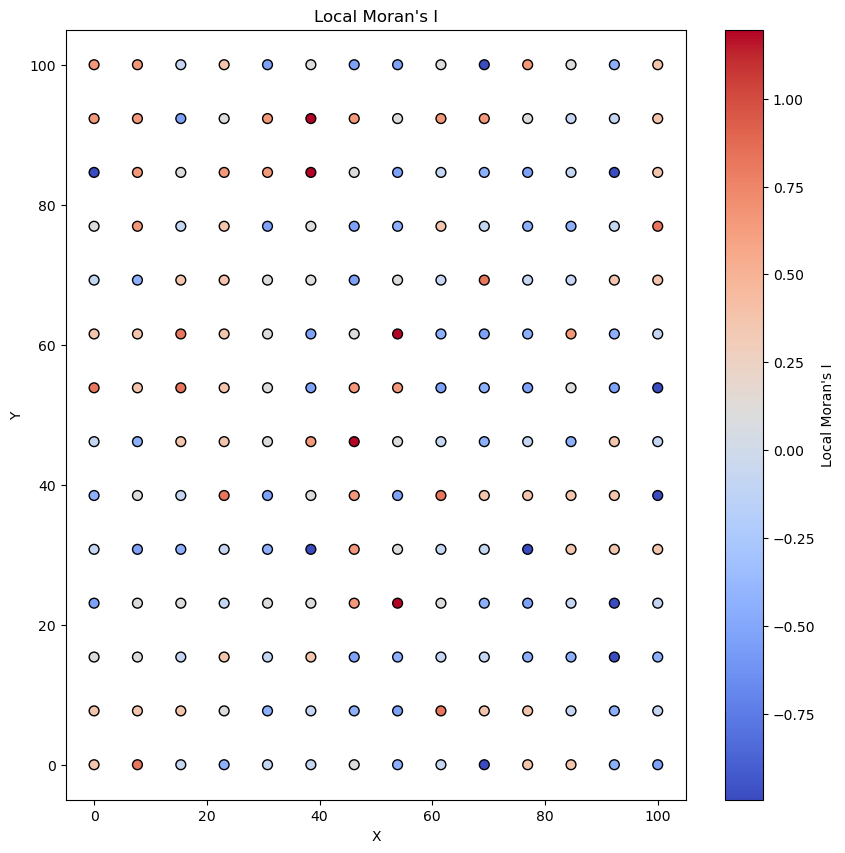

[OK] Local Moran's I map rendered.


In [9]:
# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(df['x'], df['y'], c=local_moran.Is, cmap='coolwarm', s=50, edgecolors='k')

# Add colorbar and labels
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Local Moran\'s I')
ax.set_title('Local Moran\'s I')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

print("[OK] Local Moran's I map rendered.")

### Local significance (p-values)

The permutation p-value at each point; darker values are more statistically significant.

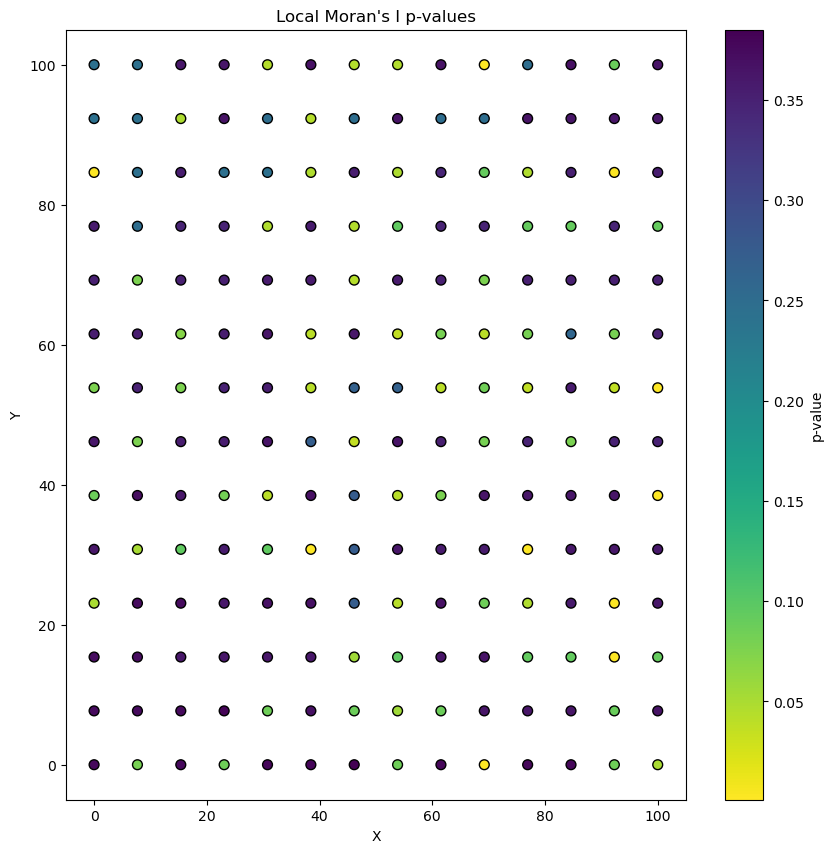

[OK] Local significance map rendered.


In [10]:
# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(df['x'], df['y'], c=local_moran.p_sim, cmap='viridis_r', s=50, edgecolors='k')

# Add colorbar and labels
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('p-value')
ax.set_title('Local Moran\'s I p-values')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

print("[OK] Local significance map rendered.")